In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import (
    load_reuters_data,
    preprocess_news
)

In [3]:
df = load_reuters_data(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/data/raw/reuters_headlines.csv"
)

df = preprocess_news(df)

df.head()

,Headlines,Time,Description,text,clean_text
0,TikTok considers London and other locations fo...,2020-07-18,TikTok has been in discussions with the UK gov...,TikTok considers London and other locations fo...,tiktok considers london and other locations fo...
1,Disney cuts ad spending on Facebook amid growi...,2020-07-18,Walt Disney has become the latest company to ...,Disney cuts ad spending on Facebook amid growi...,disney cuts ad spending on facebook amid growi...
2,Trail of missing Wirecard executive leads to B...,2020-07-18,Former Wirecard chief operating officer Jan M...,Trail of missing Wirecard executive leads to B...,trail of missing wirecard executive leads to b...
3,Twitter says attackers downloaded data from up...,2020-07-18,Twitter Inc said on Saturday that hackers were...,Twitter says attackers downloaded data from up...,twitter says attackers downloaded data from up...
4,U.S. Republicans seek liability protections as...,2020-07-17,A battle in the U.S. Congress over a new coron...,U.S. Republicans seek liability protections as...,u s republicans seek liability protections as ...


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(32770, 5)

Columns:
['Headlines', 'Time', 'Description', 'text', 'clean_text']


In [5]:
df.isnull().sum()

Headlines      0
Time           0
Description    0
text           0
clean_text     0
dtype: int64

In [6]:
print(
    "Start:",
    df["Time"].min()
)

print(
    "End:",
    df["Time"].max()
)

Start: 2018-03-20 00:00:00
End: 2020-07-18 00:00:00


In [7]:
articles_per_month = (
    df
    .set_index("Time")
    .resample("M")
    .size()
)

/var/folders/rt/v30332z529n0dn6mksfzb_p00000gn/T/ipykernel_13726/1909338268.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


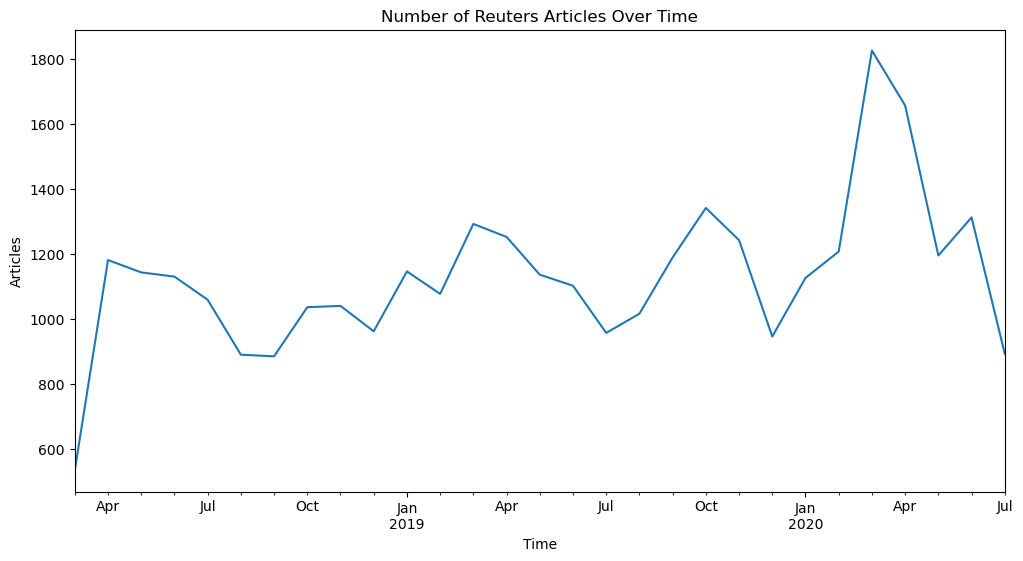

In [8]:
plt.figure(figsize=(12,6))

articles_per_month.plot()

plt.title(
    "Number of Reuters Articles Over Time"
)

plt.ylabel(
    "Articles"
)

plt.show()

In [9]:
df["length"] = (
    df["clean_text"]
    .str.split()
    .str.len()
)

In [10]:
df["length"].describe()

count    32770.000000
mean        45.825359
std          7.611892
min         13.000000
25%         41.000000
50%         46.000000
75%         51.000000
max         97.000000
Name: length, dtype: float64

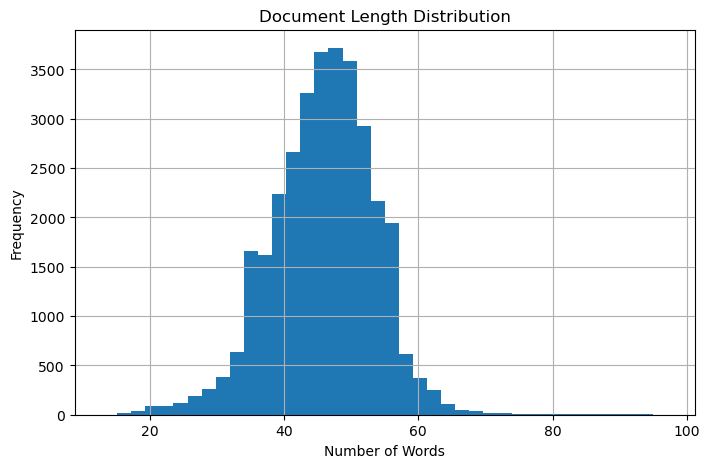

In [11]:
plt.figure(figsize=(8,5))

df["length"].hist(
    bins=40
)

plt.title(
    "Document Length Distribution"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [12]:
df[
    ["Headlines","Description"]
].sample(
    5,
    random_state=42
)

,Headlines,Description
18246,Exclusive: GAM whistle blower concerns focused...,A whistle blower at Swiss asset manager GAM Ho...
9226,Ghosn says he escaped 'injustice' in Japan; Le...,Ousted Nissan boss Carlos Ghosn said on Tuesda...
24730,"Iran says it is selling the oil it needs to, d...",Iran said on Tuesday it had so far been able t...
6478,"Twitter, Elliott in deal for Dorsey to stay CE...",Twitter Inc on Monday reached an agreement wi...
4813,Trump threatens tariffs on oil imports to 'pro...,U.S. President Donald Trump said on Saturday h...


In [13]:
df.to_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/data/processed/cleaned_news.csv",
    index=False
)